In [1]:
import os, time

import math
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable 

from skrmt.ensemble.spectral_law import MarchenkoPasturDistribution

# Following options are dependant on https://github.com/chanjure/global_chanju.git
# However, this is just an aesthetic package for plotting, so it is not necessary.
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten


set_rc() # Setting global chanju plotting scheme

In [2]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=200):
    new_cmap = LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# 0. Linear Full Batch

\begin{align}
    \epsilon_c = 1 - \left[ 1 + \sigma_W r^{\frac{1}{4}} \right]^{-\frac{1}{t}}
\end{align}

\begin{align}
    \lambda_{\rm iso} = \frac{\theta^2 \left(B^2 + \sigma_t^2\right)}{B^2}
\end{align}

\begin{align}
    A^2 &= (1 - \epsilon)^{2t}, \\
    B^2 &= \left(1 - (1 - \epsilon)^{t}\right)^2,
\end{align}

\begin{align}
    \sigma_t^2 = A^2 \sigma_W^2
\end{align}

\begin{align}
    t_c = - \frac{\ln \left[1 + \sigma_W r^{\frac{1}{4}}\right]}{\ln \left[1 - \epsilon \right]}
\end{align}

\begin{align}
    q^2 = 1 - \frac{r\sigma_t^4}{\left(B^2 - r\sigma_t^2\right)^2}
\end{align}

every calculation is valid only for $0 < \epsilon < 1$.

In [3]:
def A(epsilon, t=1):
    """ Variance rescaling
    """
    return (1 - epsilon)**(2*t)

def B(epsilon, t=1):
    """ Signal rescaling
    """
    return (1 - (1 - epsilon)**t)**2

def sigma2_t(epsilon, sigma_W, t):
    """ Rescaled bulk
    
    sigma_W: initial standard deviation of weight
    """
    return A(epsilon=epsilon, t=t) * sigma_W**2

def theta2_t(epsilon, sigma_W, r, t):
    """ Effective signal strength
    """
    return sigma2_t(epsilon=epsilon, sigma_W=sigma_W, t=t)*r + B(epsilon=epsilon, t=t)

def epsilon_c(sigma_W, r, t):
    """ Critical epsilon
    """
    return 1. - (1 + sigma_W * r**(0.25))**(-1./t)

def epsilon_c_n(sigma_W, r, t):
    eps_n = np.where(1. - (1 - sigma_W * r**(0.25))**(-1./t)>0, 1. - (1 - sigma_W * r**(0.25))**(-1./t), np.nan)
    return eps_n

def lambda_iso(epsilon, sigma_W, r, t):
    """ Location of isolated eigenvalue
    """
    a = sigma2_t(epsilon=epsilon, sigma_W=sigma_W, t=t)
    b = B(epsilon=epsilon, t=t)
    return (b + r*a)*(b + a) / b

def lambda_plus(epsilon, sigma_W, r, t=1):
    """Upper bound of the MP distribution

    Parameters:
    -----------
    r (int): Aspect ratio
    epsilon (float): step size
    sigma_W (float): Initial variance of the weight matrix   
    """
    return (1 - epsilon)**2 * sigma_W**2 * (1 + np.sqrt(r))**2

def t_c(epsilon, sigma_W, r):
    """ Critical time for dynamical BBP
    """
    return - np.log(1 + sigma_W * r**(0.25))/np.log(1 - epsilon)

def q2(epsilon, sigma_W, r, t=1):
    """ q2 Overlap
    """
    a = sigma2_t(epsilon=epsilon, sigma_W=sigma_W, t=t)
    b = B(epsilon=epsilon, t=t)
    c = b / a
    return (1. - r / c**2)/(1. + r / c)

In [4]:
plot_dir0 = "../images/0.linear_full_batch/"
data_dir0 = "../data/0.linear_full_batch/"

os.system("mkdir -p " + plot_dir0)
os.system("mkdir -p " + data_dir0)

0

## BBP phase diagram

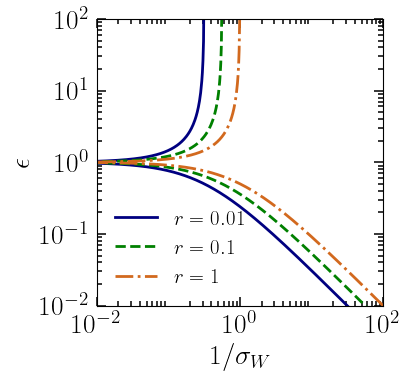

In [5]:
figure_id = "phase_boundary_r"

set_rc(scale=1.1)

sigma_list = np.logspace(-2, 2, 500)

r_list = [0.01, 0.1, 1]
colours = ['navy', 'green', 'chocolate']
lines = ['-', '--', '-.']
labels = ['0.01', '0.1', '1']
x_plot = 1./sigma_list

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))


for i, r in enumerate(r_list):
    axs.plot(x_plot, epsilon_c(sigma_list, r, t=1),
             color=colours[i], ls=lines[i], 
             lw=2,
             marker='',
             label=r"$r = %s$"%(labels[i])
            )
    val_epsc_n = np.where(epsilon_c_n(sigma_list, r, t=1)>1e-15, epsilon_c_n(sigma_list, r, t=1), np.nan)
    axs.plot(x_plot, val_epsc_n,
             color=colours[i], ls=lines[i], 
             lw=2,
             marker='',
            )

nice_style(axs,
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$"
          )

plt.legend(loc="lower left", fontsize=15)
plt.tight_layout()

axs.set_aspect("equal", adjustable="box")

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")
plt.show()

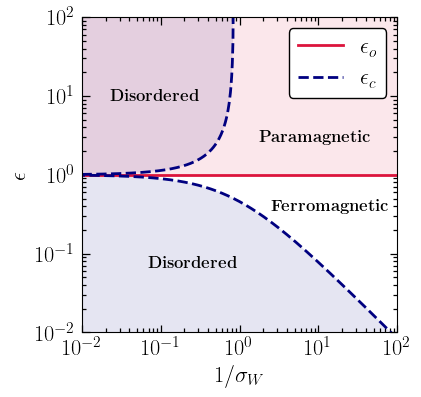

In [6]:
set_rc(scale=0.9)

figure_id = "phase_boundary"

sigma_list = np.logspace(-2, 2, 500)

x_plot = 1./sigma_list

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

epsilon_o = np.ones_like(sigma_list)
axs.plot(x_plot, epsilon_o, 
         color='crimson', ls='-', lw=2,
         marker='',
         label=r"$\epsilon_o$"
        )

axs.plot(x_plot, epsilon_c(sigma_list, r=0.5, t=1),
         color="navy", ls="--", lw=2,
         marker='',
         label=r"$\epsilon_c$"
        )
axs.plot(x_plot, epsilon_c_n(sigma_list, r=0.5, t=1),
         color="navy", ls="--", lw=2,
         marker='',
        )

axs.fill_between(1./sigma_list, y1=1e-2, y2=epsilon_c(sigma_list, r=0.5, t=1), 
                 facecolor='navy', alpha=0.1, hatch='')
axs.fill_between(1./sigma_list, y1=epsilon_c_n(sigma_list, r=0.5, t=1), y2=1e2, 
                 facecolor='navy', alpha=0.1, hatch='')
axs.fill_between(1./sigma_list, y1=epsilon_o, y2=1e2, 
                 facecolor='crimson', alpha=0.1, hatch='')

fontsize=12

axs.text(
    0.09, 0.75,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Disordered",
    fontsize=fontsize
)

axs.text(
    0.56, 0.62,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Paramagnetic",
    fontsize=fontsize
)

axs.text(
    0.6, 0.4,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Ferromagnetic",
    fontsize=fontsize
)

axs.text(
    0.21, 0.22,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Disordered",
    fontsize=fontsize
)

nice_style(axs,
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$"
          )

plt.legend(loc='upper right', 
           facecolor='white', frameon=True, framealpha=1, 
           edgecolor='k', fancybox=True,
#            fontsize=18
          )

axs.set_aspect("equal", adjustable="box")

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")
plt.show()

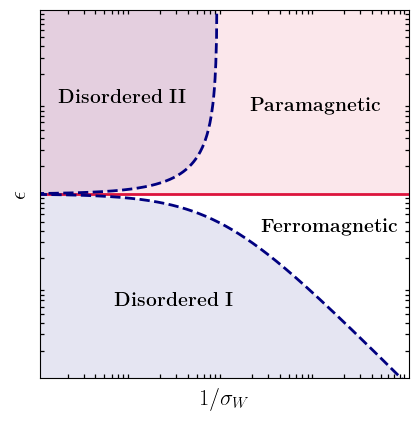

In [310]:
# For introduction

set_rc(scale=0.9)

figure_id = "phase_boundary"

sigma_list = np.logspace(-2, 2, 500)

x_plot = 1./sigma_list

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

epsilon_o = np.ones_like(sigma_list)
axs.plot(x_plot, epsilon_o, 
         color='crimson', ls='-', lw=2,
         marker='',
         label=r"$\epsilon_o$"
        )

axs.plot(x_plot, epsilon_c(sigma_list, r=0.5, t=1),
         color="navy", ls="--", lw=2,
         marker='',
         label=r"$\epsilon_c$"
        )
axs.plot(x_plot, epsilon_c_n(sigma_list, r=0.5, t=1),
         color="navy", ls="--", lw=2,
         marker='',
        )

axs.fill_between(1./sigma_list, y1=1e-2, y2=epsilon_c(sigma_list, r=0.5, t=1), 
                 facecolor='navy', alpha=0.1, hatch='')
axs.fill_between(1./sigma_list, y1=epsilon_c_n(sigma_list, r=0.5, t=1), y2=1e2, 
                 facecolor='navy', alpha=0.1, hatch='')
axs.fill_between(1./sigma_list, y1=epsilon_o, y2=1e2, 
                 facecolor='crimson', alpha=0.1, hatch='')

fontsize=14

axs.text(
    0.05, 0.76,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Disordered II",
    fontsize=fontsize
)

axs.text(
    0.57, 0.74,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Paramagnetic",
    fontsize=fontsize
)

axs.text(
    0.6, 0.41,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Ferromagnetic",
    fontsize=fontsize
)

axs.text(
    0.2, 0.21,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Disordered I",
    fontsize=fontsize
)

nice_style(axs,
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$",
           xticks=[], yticks=[],
          )

# plt.tick_params( 
#     axis='both',
#     which='major',
#     bottom=True,     
#     top=True,
#     left=True,
#     right=True,
# )

axs.set_aspect("equal", adjustable="box")

plt.tight_layout()

plt.savefig(plot_dir0+"intro_"+figure_id+".pdf")
plt.show()

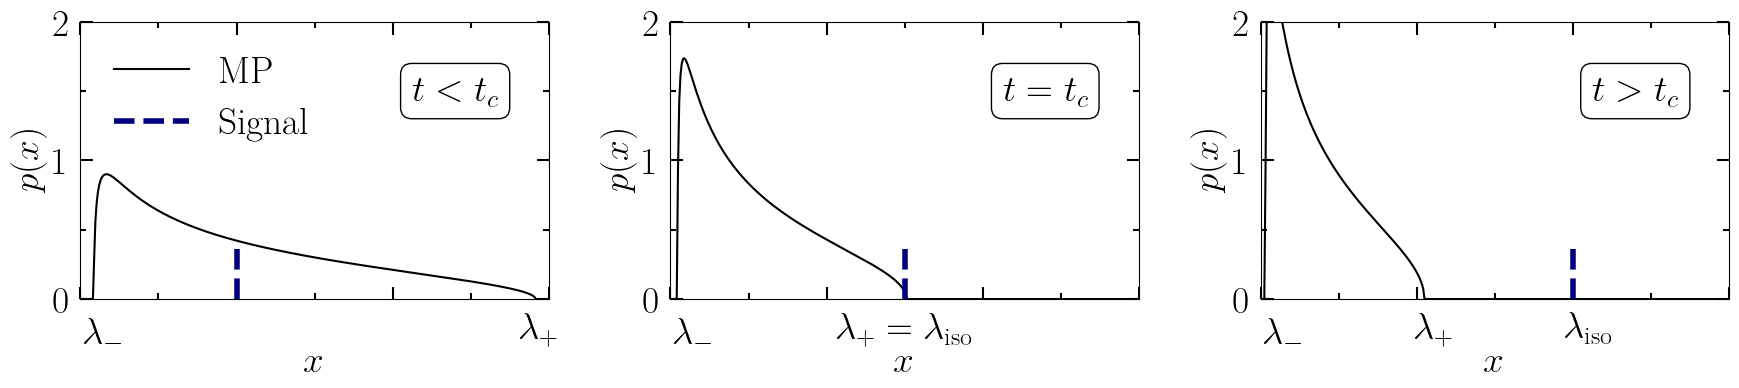

In [228]:
set_rc(scale=1.5)

x_plot = np.linspace(0., 4., 500)

n_fig = 3
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

mpd = MarchenkoPasturDistribution(beta=1, ratio=0.5, 
                                  sigma=1.)
y_plot = mpd.pdf(x_plot)

axs[0].plot(
    x_plot, y_plot,
    ls='-', marker='', color='k',
    label=r"MP"
)

# Signal
axs[0].axvline(
    x=1.,
    ymin=0, ymax=0.2,
    color='navy', ls='--', lw=4,
    label=r"Signal"
)

axs[0].legend(loc="upper left")

# Bulk edge
lambda_p = (1 + np.sqrt(0.5))**2
lambda_m = (1 - np.sqrt(0.5))**2

axs[0].text(
    0.05, -0.1,
    transform=axs[0].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$\lambda_{-}$",
)

axs[0].text(
    0.98, -0.11,
    transform=axs[0].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$\lambda_{+}$",
)

axs[0].text(
    0.8, 0.75,
    transform=axs[0].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$t < t_c$",
    bbox=dict(facecolor='white', boxstyle='round')
)

nice_style(
    axs[0],
    xlim=(0, 3), ylim=(0, 2),
    xlabel=r"$x$", ylabel=r"$p(x)$",
    xtick_label=[]
)

axs[0].xaxis.labelpad=25

#########################

sig_ = 0.72
mpd = MarchenkoPasturDistribution(beta=1, ratio=0.5, 
                                  sigma=sig_)
y_plot = mpd.pdf(x_plot)

axs[1].plot(
    x_plot, y_plot,
    ls='-', marker='', color='k',
    label=r"MP"
)

# Signal
axs[1].axvline(
    x=1.5,
    ymin=0, ymax=0.2,
    color='navy', ls='--', lw=4,
    label=r"Signal"
)


# Bulk edge
lambda_p = sig_**2 * (1 + np.sqrt(0.5))**2
lambda_m = sig_**2 * (1 - np.sqrt(0.5))**2

axs[1].text(
    0.05, -0.1,
    transform=axs[1].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$\lambda_{-}$",
)

axs[1].text(
    0.5, -0.11,
    transform=axs[1].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$\lambda_{+}=\lambda_{\rm iso}$",
)

axs[1].text(
    0.8, 0.75,
    transform=axs[1].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$t = t_c$",
    bbox=dict(facecolor='white', boxstyle='round')
)

nice_style(
    axs[1],
    xlim=(0, 3), ylim=(0, 2),
    xlabel=r"$x$", ylabel=r"$p(x)$",
    xtick_label=[]
)

axs[1].xaxis.labelpad=25


###############################
mpd = MarchenkoPasturDistribution(beta=1, ratio=0.5, 
                                  sigma=0.6)
y_plot = mpd.pdf(x_plot)

axs[2].plot(
    x_plot, y_plot,
    ls='-', marker='', color='k',
    label=r"MP"
)

# Signal
axs[2].axvline(
    x=2,
    ymin=0, ymax=0.2,
    color='navy', ls='--', lw=4,
    label=r"Signal"
)

axs[2].text(
    0.7, -0.11,
    transform=axs[2].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$\lambda_{\rm iso}$",
)

lambda_p = 0.6**2 * (1 + np.sqrt(0.5))**2
lambda_m = 0.6**2 * (1 - np.sqrt(0.5))**2

axs[2].text(
    0.05, -0.1,
    transform=axs[2].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$\lambda_{-}$",
)

axs[2].text(
    0.37, -0.11,
    transform=axs[2].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$\lambda_{+}$",
)
# axs[1].legend(loc="upper left")

axs[2].text(
    0.8, 0.75,
    transform=axs[2].transAxes,
    horizontalalignment='center', verticalalignment='center',
    color='k', 
    s=r"$t > t_c$",
    bbox=dict(facecolor='white', boxstyle='round')
)

nice_style(
    axs[2],
    xlim=(0, 3), ylim=(0, 2),
    xlabel=r"$x$", ylabel=r"$p(x)$",
    xtick_label=[],
)

axs[2].xaxis.labelpad=25

plt.tight_layout()

plt.savefig(plot_dir0+"intro_fm.pdf")

plt.show()

## Eigenvector overlap

Loaded the figure from ../data/0.linear_full_batch/fig_q2_overlap_N100.npz


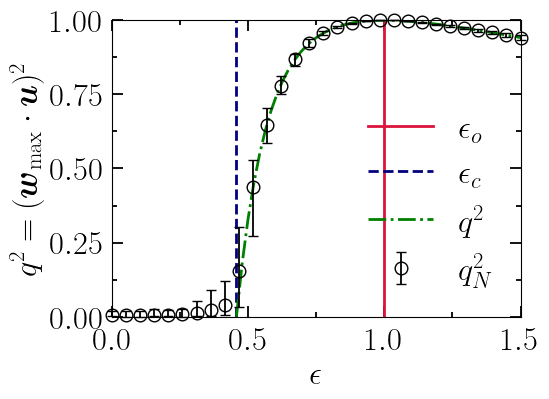

In [258]:
sigma = 1.
epsilon_list = np.linspace(0, 1.5, 30)

n = 100

N = 100
M = 200

r = N / M

figure_id = "q2_overlap_N%d"%(N)

W_star = np.zeros((n, N, M))
W_star[:, 0, 0] = 1

try:
    with np.load(data_dir0+"fig_"+figure_id+".npz") as data:
        x_plot = data["x_plot"]
        y_mean = data["y_mean"]
        y_err = data["y_err"]
        x_list = data["x_list"]
        q2_list = data["q2_list"]
        u_list = data["u_list"]
        
    print("Loaded the figure from "+data_dir0+"fig_"+figure_id+".npz")
    
except:
    x_list = np.zeros((len(epsilon_list), n, N))
    q2_list = np.zeros((len(epsilon_list), n))
    u_list = np.zeros((len(epsilon_list), n, N))

    for e, epsilon in enumerate(epsilon_list):
        print("measuring ", e, epsilon)
        W0 = np.random.normal(0., sigma/np.sqrt(M), size=(n, N, M))

        dl = - (W_star - W0)

        W_prime = W0 - epsilon * dl
        Xp = np.einsum("nac, nbc -> nab", W_prime, W_prime)
        x, u = np.linalg.eig(Xp)
        x_list[e] = x.copy()
        
        u_list[e] = u[:, 0].copy()

        q2_ = u[:, 0, 0]**2
        q2_list[e] = q2_.copy()

    print("done")
    
    x_plot = epsilon_list
    med, err = asym_err(q2_list, axis=1)
    y_mean = med
    y_err = err
    
    np.savez(data_dir0+"fig_"+figure_id+".npz", 
             x_plot = x_plot,
             y_mean = y_mean,
             y_err = y_err,
             x_list = x_list,
             q2_list = q2_list,
             u_list = u_list,
            )
    print("Saved the figure to "+data_dir0+"fig_"+figure_id+".npz")


n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

eps_0 = 1.
axs.axvline(eps_0,
            ls='-', color='crimson', lw=2,
            label=r"$\epsilon_o$")

eps_c = epsilon_c(sigma, r, t=1)
axs.axvline(eps_c, 
            ls='--', lw=2, color='navy',
            label=r"$\epsilon_c$")

x_q2 = np.linspace(eps_c, 1.5, 50)
q2_pred = q2(x_q2, 1., 0.5, t=1)
axs.plot(x_q2, q2_pred, 
         ls='-.', lw=2, marker='', color='green', 
         label=r"$q^2$")

axs.errorbar(x_plot, y_mean, yerr=y_err, 
             ls='', clip_on=False,
             color='k', label=r"$q^2_N$")

nice_style(axs, 
           xlim=(0., max(epsilon_list)), ylim=(0.,1.), 
           xlabel=r"$\epsilon$", ylabel=r"$q^2 = (\boldsymbol{w}_{\rm max} \cdot \boldsymbol{u})^2$")

plt.legend(loc='lower right')

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

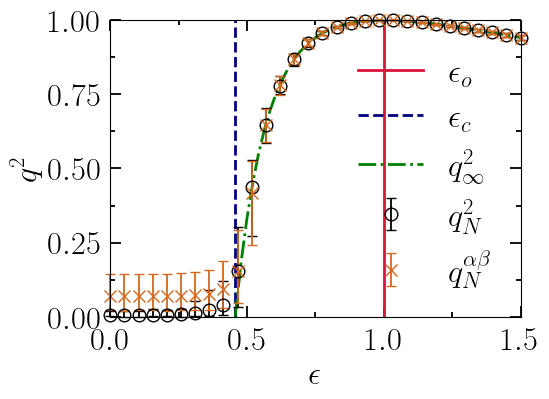

In [259]:
figure_id = "effective_orderparameter"

u_ab = []
for i in range(n):
    for j in range(i+1, n):
#         u_ab.append((np.sum(u_list[:, i] * u_list[:, j], axis=-1))**2)
        u_ab.append(np.abs(np.sum(u_list[:, i] * u_list[:, j], axis=-1)))

        
u_ab = np.array(u_ab)

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

eps_0 = 1.
axs.axvline(eps_0,
            ls='-', color='crimson', lw=2,
            label=r"$\epsilon_o$")

eps_c = epsilon_c(sigma, r, t=1)
axs.axvline(eps_c, 
            ls='--', lw=2, color='navy',
            label=r"$\epsilon_c$")

x_q2 = np.linspace(eps_c, 1.5, 50)
q2_pred = q2(x_q2, 1., 0.5, t=1)
axs.plot(x_q2, q2_pred, 
         ls='-.', lw=2, marker='', color='green', 
         label=r"$q^2_{\infty}$")

axs.errorbar(x_plot, y_mean, yerr=y_err, 
             ls='', clip_on=False,
             color='k', label=r"$q^2_N$")

med, err = asym_err(u_ab, axis=0)
axs.errorbar(epsilon_list, med, yerr=err,
             ls='', clip_on=False,
             color='chocolate', label=r"$q^{\alpha \beta}_N$")

nice_style(axs, 
           xlim=(0., max(epsilon_list)), ylim=(0.,1.), 
           xlabel=r"$\epsilon$", ylabel=r"$q^2$")

plt.legend(loc='lower right')

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

## Isolated Eigenvalue

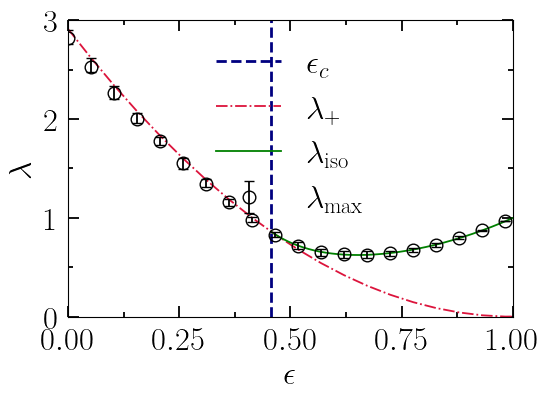

In [260]:
figure_id = "lbd_flow"

sigma = 1.
r = 0.5

eps_c = epsilon_c(sigma, r, t=1)

epsilon_list = np.linspace(0, 1.5, 30)

# MP edge
lambda_plus_plot = lambda_plus(epsilon_list, sigma, r)

# Top eigenvalue
lambda_top = np.max(x_list, axis=-1)

# Isolated eigenvalue
x_fine = np.linspace(eps_c, max(epsilon_list), 1000)
lambda_iso_plot = lambda_iso(x_fine, sigma, r=r, t=1)

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

# RMT critical epsilon
axs.axvline(eps_c, ls='--', lw=2,
            color='navy', label=r"$\epsilon_c$")

# MP edge
axs.plot(epsilon_list, lambda_plus_plot, ls='-.', 
         color='crimson', label=r"$\lambda_{+}$", marker='')

axs.plot(x_fine, lambda_iso_plot, 
         color='green', label=r"$\lambda_{\rm iso}$", ls='-', marker='')

# Experimental maximum eigenvalue
med, err = asym_err(lambda_top, axis=1)
axs.errorbar(epsilon_list, med, err, 
             color='k', clip_on=True,
             label=r"$\lambda_{\rm max}$", ls='')

nice_style(axs, xlim=(0., 1.), ylim=(0, 3), 
           xlabel=r"$\epsilon$", ylabel=r"$\lambda$")

plt.legend()

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")
plt.show()

## Monte Carlo Simulation

In [261]:
def identity(x):
    return x

def identityp(x):
    return np.ones_like(x)

def identitypp(x):
    return np.zeros_like(x)

In [262]:
def simulate(epsilon, sigma, N, M, n_try, n_data, f, fp, data_dir):
    
    r = N/M
    
    # Load or generate data
    data_string = "N%d_r%.2f_eps%.5f_sig%.5f"%(N, r, epsilon, sigma)
    print(data_string)

    if data_string+"_data.npz" in os.listdir(data_dir):
        load = True
        print("Load data from "+data_dir+data_string+"_data.npz")
    else:
        load = False

    W_star = np.zeros((N, M))
    W_star[0][0] = 1
    README = ""

    if load:
        data = np.load(data_dir+data_string+"_data.npz")
        README = data["README"]
        W_list = data["W_list"]
        l_list = data["l_list"]
        dl_list = data["dl_list"]

        print("Data loaded from: "+data_dir+data_string+"_data.npz")
    else:
        print("=====")
        print("Generating ... ")
        W_list = np.zeros((n_try, 2, N, M))
        l_list = np.zeros((n_try, 2))
        dl_list = np.zeros((n_try))

        for n in range(n_try):
            data = np.random.normal(0., 1., size=(n_data, M))
            W0 = np.random.normal(0., sigma/np.sqrt(M), size=(N, M))

            W_list[n][0] = W0.copy()

            h_hat = data @ W0.T # n x M

            y_hat = f(h_hat) # n x M
            y = f(data @ W_star.T) # n x M

            l_ = 0.5*np.trace((y - y_hat) @ (y - y_hat).T)/n_data

            l_list[n][0] = l_.copy()

            dl = - np.mean(np.einsum("nM, nN, nN -> nNM", 
                                     data, y - y_hat, fp(h_hat)), 
                           axis=0)
            
            dl_list[n] = np.linalg.norm(dl)

            # Single Step Update
            W_ = W0 - epsilon * dl

            W_list[n][1] = W_.copy()

            h_hat = data @ W_.T # n x M

            y_hat = f(h_hat) # n x M
            y = f(data @ W_star.T) # n x M

            l_ = 0.5*np.trace((y - y_hat) @ (y - y_hat).T)/n_data

            l_list[n][1] = l_.copy()

        # Generate the docstring
        README = """
        N: %d
        M: %d
        r: %.4f
        eps: %.4f
        sig: %.4f
        n_try: %d
        """%(N, M, r, epsilon, sigma, n_try)

        np.savez(data_dir+data_string+"_data.npz",
                 README = README,
                 W_list = W_list, 
                 l_list = l_list,
                 dl_list = dl_list,
                )

        print("Data saved to "+data_dir+data_string+"_data.npz")
        print(README)
        print("=====")

In [263]:
# Generate single step trained networks
# The size of the generated data is a bit large, I will share it with you via email if you want.

N = 100
M = 200
r = N/M

n_try = 5
n_data = 3000

f = identity
fp = identityp
fpp = identitypp
    
epsilon_list = np.logspace(-2, 2, 10)
sigma_list = np.logspace(-2, 2, 10)

for epsilon in epsilon_list:
    for sigma in sigma_list:
        simulate(epsilon, sigma, 
                 N=N, M=M, 
                 n_try=n_try, 
                 n_data=n_data, 
                 f=f, fp=fp, 
                 data_dir=data_dir0)
        
print("done")

N100_r0.50_eps0.01000_sig0.01000
Load data from ../data/0.linear_full_batch/N100_r0.50_eps0.01000_sig0.01000_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps0.01000_sig0.01000_data.npz
N100_r0.50_eps0.01000_sig0.02783
Load data from ../data/0.linear_full_batch/N100_r0.50_eps0.01000_sig0.02783_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps0.01000_sig0.02783_data.npz
N100_r0.50_eps0.01000_sig0.07743
Load data from ../data/0.linear_full_batch/N100_r0.50_eps0.01000_sig0.07743_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps0.01000_sig0.07743_data.npz
N100_r0.50_eps0.01000_sig0.21544
Load data from ../data/0.linear_full_batch/N100_r0.50_eps0.01000_sig0.21544_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps0.01000_sig0.21544_data.npz
N100_r0.50_eps0.01000_sig0.59948
Load data from ../data/0.linear_full_batch/N100_r0.50_eps0.01000_sig0.59948_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_e

Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps0.21544_sig100.00000_data.npz
N100_r0.50_eps0.59948_sig0.01000
Load data from ../data/0.linear_full_batch/N100_r0.50_eps0.59948_sig0.01000_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps0.59948_sig0.01000_data.npz
N100_r0.50_eps0.59948_sig0.02783
Load data from ../data/0.linear_full_batch/N100_r0.50_eps0.59948_sig0.02783_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps0.59948_sig0.02783_data.npz
N100_r0.50_eps0.59948_sig0.07743
Load data from ../data/0.linear_full_batch/N100_r0.50_eps0.59948_sig0.07743_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps0.59948_sig0.07743_data.npz
N100_r0.50_eps0.59948_sig0.21544
Load data from ../data/0.linear_full_batch/N100_r0.50_eps0.59948_sig0.21544_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps0.59948_sig0.21544_data.npz
N100_r0.50_eps0.59948_sig0.59948
Load data from ../data/0.linear_full_batch/N100_r0.50

Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps12.91550_sig100.00000_data.npz
N100_r0.50_eps35.93814_sig0.01000
Load data from ../data/0.linear_full_batch/N100_r0.50_eps35.93814_sig0.01000_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps35.93814_sig0.01000_data.npz
N100_r0.50_eps35.93814_sig0.02783
Load data from ../data/0.linear_full_batch/N100_r0.50_eps35.93814_sig0.02783_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps35.93814_sig0.02783_data.npz
N100_r0.50_eps35.93814_sig0.07743
Load data from ../data/0.linear_full_batch/N100_r0.50_eps35.93814_sig0.07743_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps35.93814_sig0.07743_data.npz
N100_r0.50_eps35.93814_sig0.21544
Load data from ../data/0.linear_full_batch/N100_r0.50_eps35.93814_sig0.21544_data.npz
Data loaded from: ../data/0.linear_full_batch/N100_r0.50_eps35.93814_sig0.21544_data.npz
N100_r0.50_eps35.93814_sig0.59948
Load data from ../data/0.linear_full_ba

In [264]:
def calculate_dx(epsilon, sigma, data_dir):
    # Load or generate data
    data_string = "N%d_r%.2f_eps%.5f_sig%.5f"%(N, r, epsilon, sigma)
    print("Loading " + data_string)

    with np.load(data_dir+data_string+"_data.npz") as data:
        W_list = data["W_list"][:, 1]

    Xp = np.einsum("nNM, nLM -> nNL", W_list, W_list)
    x, u = np.linalg.eig(Xp)
       
    diff = (x[:, 0] - x[:, 1]) / x[:, 0]
    q2_ = u[:, 0, 0]**2
    
    u_ab = []
    
    w_vec = W_list.reshape(len(W_list), -1)
    w_norm = w_vec / np.linalg.norm(w_vec, axis=-1, keepdims=True)
    w_ab = []
    
    for i in range(u.shape[0]):
        for j in range(i+1, u.shape[0]):
#             u_ab.append((np.sum(u[i, 0] * u[j, 0], axis=-1))**2)
            u_ab.append(np.abs(np.sum(u[i, 0] * u[j, 0], axis=-1)))
            w_ab.append(np.abs(np.sum(w_norm[i] * w_norm[j], axis=-1)))
            
    u_ab = np.array(u_ab)
    w_ab = np.array(w_ab)
    
    W_star = np.zeros_like(W_list)
    W_star[:, 0, 0] = 1
    w_star = W_star.reshape(len(W_list), -1)
    w_st = np.sum(w_norm*w_star, axis=-1)**2

    return diff, q2_, u_ab, w_ab, w_st

In [265]:
try:
    with np.load(data_dir0+"q2_diff_measure.npz") as data:
        diff_list = data["diff_list"]
        diff_err_list = data["diff_err_list"]
        q2_list = data["q2_list"]
        q2_err_list = data["q2_err_list"]
        u_ab_list = data["u_ab_list"]
        u_ab_err_list = data["u_ab_err_list"]
        w_ab_list = data["w_ab_list"]
        w_ab_err_list = data["w_ab_err_list"]
        w_st_list = data["w_st_list"]
        w_st_err_list = data["w_st_err_list"]
        
    print("Load from "+data_dir0 +"q2_diff_measure.npz")
        
except:
    diff_list = np.zeros((len(sigma_list), len(epsilon_list)))
    diff_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

    q2_list = np.zeros((len(sigma_list), len(epsilon_list)))
    q2_err_list = np.zeros((len(sigma_list), len(epsilon_list)))
    
    u_ab_list = np.zeros((len(sigma_list), len(epsilon_list)))
    u_ab_err_list = np.zeros((len(sigma_list), len(epsilon_list)))
    
    w_ab_list = np.zeros((len(sigma_list), len(epsilon_list)))
    w_ab_err_list = np.zeros((len(sigma_list), len(epsilon_list)))
    
    w_st_list = np.zeros((len(sigma_list), len(epsilon_list)))
    w_st_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

    for i, epsilon in enumerate(epsilon_list):
        for j, sigma in enumerate(sigma_list):
            diff, q2, u_ab, w_ab, w_st = calculate_dx(epsilon, sigma, data_dir0)

            diff_list[j, i] = np.mean(diff, axis=0)
            diff_err_list[j, i] = np.std(diff, axis=0)

            q2_list[j, i] = np.mean(q2, axis=0)
            q2_err_list[j, i] = np.std(q2, axis=0)  
            
            u_ab_list[j, i] = np.mean(u_ab, axis=0)
            u_ab_err_list[j, i] = np.std(u_ab, axis=0)
            
            w_ab_list[j, i] = np.mean(w_ab, axis=0)
            w_ab_err_list[j, i] = np.std(w_ab, axis=0)
            
            w_st_list[j, i] = np.mean(w_st, axis=0)
            w_st_err_list[j, i] = np.std(w_st, axis=0)
            
    np.savez(data_dir0+"q2_diff_measure.npz",
             diff_list = diff_list,
             diff_err_list = diff_err_list,
             q2_list = q2_list,
             q2_err_list = q2_err_list,
             u_ab_list = u_ab_list,
             u_ab_err_list = u_ab_err_list,
             w_ab_list = w_ab_list,
             w_ab_err_list = w_ab_err_list,
             w_st_list = w_st_list,
             w_st_err_list = w_st_err_list
            )
    
    print("Saved to "+data_dir0 +"q2_diff_measure.npz")

print("done")

Load from ../data/0.linear_full_batch/q2_diff_measure.npz
done


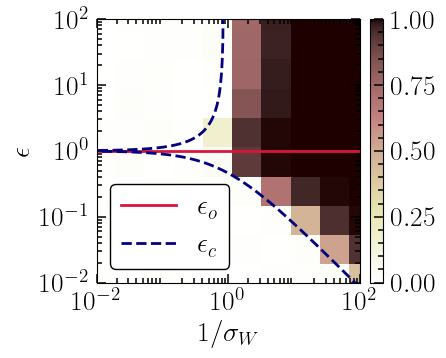

In [266]:
sigma_fine = np.logspace(-2, 2, 500)
eps_c = epsilon_c(sigma_fine, r=r, t=1)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=1)

set_rc(scale=1.1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, q2_list.T,
                    vmin=0, vmax=1,
                    cmap='pink_r',
                    shading='auto')

# Optimal epsilon
axs.plot(1./sigma_list, np.ones_like(sigma_list), 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

# Critical step size
axs.plot(1./sigma_fine, eps_c, 
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sigma_fine, eps_c_n, 
         color='navy', marker='', ls='--', lw=2,)

plt.legend(loc='lower left', facecolor='white', frameon=True, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir0 + "linear_q2_exp.pdf", bbox_inches="tight")

plt.show()

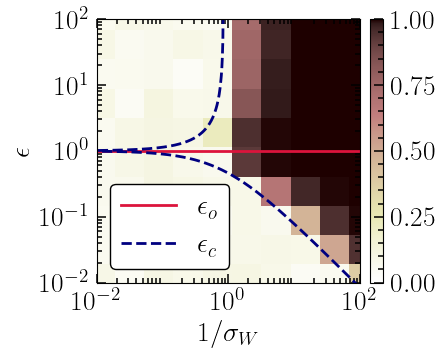

In [267]:
sigma_fine = np.logspace(-2, 2, 500)
eps_c = epsilon_c(sigma_fine, r=r, t=1)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=1)

set_rc(scale=1.1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, u_ab_list.T,
                    vmin=0, vmax=1,
                    cmap='pink_r',
                    shading='auto')

# Optimal epsilon
axs.plot(1./sigma_list, np.ones_like(sigma_list), 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

# Critical step size
axs.plot(1./sigma_fine, eps_c, 
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sigma_fine, eps_c_n, 
         color='navy', marker='', ls='--', lw=2,)

plt.legend(loc='lower left', facecolor='white', frameon=True, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir0 + "linear_u_ab_exp.pdf", bbox_inches="tight")

plt.show()

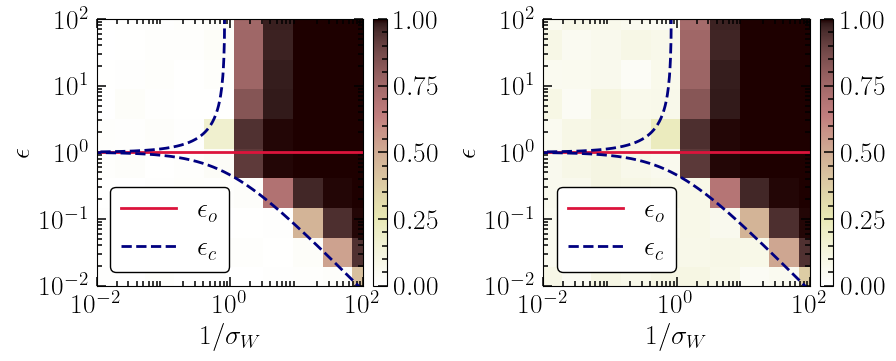

In [268]:
sigma_fine = np.logspace(-2, 2, 500)
eps_c = epsilon_c(sigma_fine, r=r, t=1)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=1)

set_rc(scale=1.1)
n_fig = 2

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

im = axs[0].pcolormesh(
    1./X, Y, q2_list.T,
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
axs[0].plot(
    1./sigma_list, np.ones_like(sigma_list), 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
axs[0].plot(
    1./sigma_fine, eps_c, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[0].plot(
    1./sigma_fine, eps_c_n, 
    color='navy', marker='', ls='--', lw=2,
)

axs[0].legend(
    loc='lower left', 
    facecolor='white', 
    frameon=True, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[0], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[0].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)


# Experimental phase diagram
im = axs[1].pcolormesh(
    1./X, Y, u_ab_list.T,
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
axs[1].plot(
    1./sigma_list, np.ones_like(sigma_list), 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
axs[1].plot(
    1./sigma_fine, eps_c, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[1].plot(
    1./sigma_fine, eps_c_n, 
    color='navy', marker='', ls='--', lw=2,
)

axs[1].legend(
    loc='lower left', 
    facecolor='white', 
    frameon=True, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[1], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[1].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir0 + "linear_exp_all.pdf", bbox_inches="tight")

plt.show()

In [269]:
N = 100
M = 200
r = N/M

n_try = 50

epsilon = 0.6
sigma = 1.

W_list = np.zeros((n_try, 2, N, M))
W_star = np.zeros((N, M))
W_star[0, 0] = 1

for n in range(n_try):
    data = np.random.normal(0., 1., size=(n_data, M))
    W0 = np.random.normal(0., sigma/np.sqrt(M), size=(N, M))


    W_list[n][0] = W0.copy()

    dl = - (W_star - W0)

    # Single Step Update
    W_ = W0 - epsilon * dl

    W_list[n][1] = W_.copy()
    
X = np.einsum("nac, nbc -> nab", W_list[:, 1], W_list[:, 1])
x = np.linalg.eigvals(X)

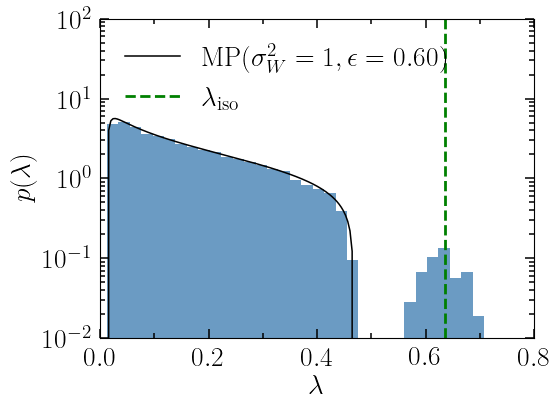

In [270]:
n_fig =1
fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W'],
             get_rc()['W']*get_rc()['r']),
)

y_hist = x.flatten()
n_bin, xran, _, _ = f_bin(y_hist)
axs.hist(y_hist, bins=n_bin, range=xran, density=True, color='steelblue', alpha=0.8)

mpd = MarchenkoPasturDistribution(beta=1, ratio=r, sigma=(1. - epsilon)*sigma)

x_plot = np.linspace(1e-5, 4, 1000)
y_plot = mpd.pdf(x_plot)
axs.plot(x_plot, y_plot, color='k', marker='', label=r"MP$(\sigma_W^2 = 1, \epsilon=%.2f)$"%(epsilon))

lbd_iso = lambda_iso(epsilon, sigma, r, t=1)
axs.axvline(lbd_iso, color='green', lw=2, ls='--', label=r"$\lambda_{\rm iso}$")

nice_style(axs, 
           ylim=(1e-2, 1e2),
           xlim=(0, 0.8),
           xlabel=r"$\lambda$",
           ylabel=r"$p(\lambda)$",
           logy=True
          )

plt.legend(loc="upper left")

plt.savefig(plot_dir0 + "linear_p_lambda_eps%.2f.pdf"%(epsilon), bbox_inches="tight")

plt.show()

# 1. Linear Full batch dynamics

## Running $\epsilon_c$

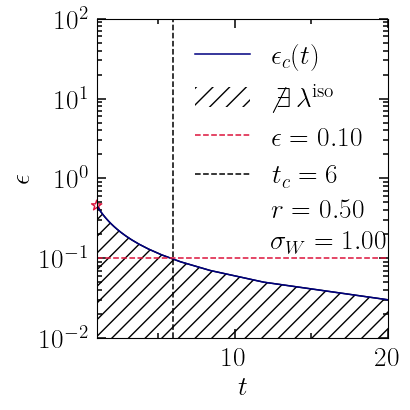

In [271]:
epsilon_list = np.linspace(0.01, 0.99, 50)
sigma = 1.
r = 0.5

epsilon = 0.1

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

t_list = t_c(epsilon_list, sigma_W=sigma, r=r)

axs.plot(t_list, epsilon_list, 
         ls='-', marker='', color='navy',
         label=r"$\epsilon_c (t)$"
        )

axs.scatter([1], epsilon_c(sigma_W=1, r=r, t=1),
            marker='*', facecolor='none', color='crimson',
            clip_on=False
           )

axs.fill_between(t_list, epsilon_list, 
                 facecolor='none', hatch="//",
                 label=r"$\not \exists \, \lambda^{\rm iso}$"
                )

axs.axhline(epsilon, ls='--', 
            color='crimson', 
            label=r"$\epsilon = %.2f$"%(epsilon))

t_crit = np.round(t_c(epsilon, sigma_W=sigma, r=r))
axs.axvline(t_crit, ymin=0, ymax=1.,
            ls='--', color='k',
            label=r"$t_c = %d$"%(t_crit)
           )

nice_style(axs,
           xlim=(1, 20), ylim=(1e-2,1e2),
           xlabel=r"$t$", ylabel=r"$\epsilon$",
           logy=True
          )

axs.text(0.6, 0.3,
            transform=axs.transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
            s=r"$\sigma_W = %.2f$"%(sigma)
           )

axs.text(0.6, 0.4,
            transform=axs.transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
            s=r"$r = %.2f$"%(r)
           )

plt.legend(loc="upper right")

plt.tight_layout()

plt.savefig(plot_dir0+"linear_running_eps.pdf")

plt.show()

## Time dependent phase diagram

/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_44150/1202358949.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


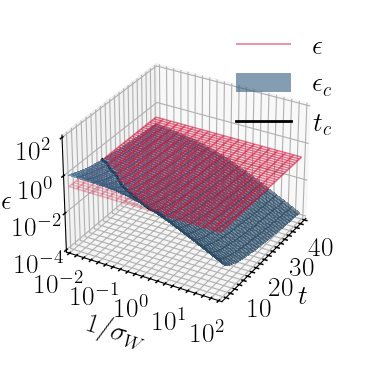

In [280]:
# epsilon = 0.01
epsilon = 0.1
# epsilon = 0.25

t_max = 40
t_list = np.arange(1, t_max)

sigma_list = np.logspace(-2, 2, 20)
   
XX, YY = np.meshgrid(t_list, sigma_list)
eps_c_list = epsilon_c(sigma_W=1./YY, r=r, t=XX)

def const_eps(x, y, eps):
    return 0.5*(x/x + y/y)*eps # To keep the shape

eps_init = const_eps(XX, YY, epsilon)

t_c_list = np.round(t_c(epsilon=epsilon, sigma_W=sigma_list, r=r))

valid1 = np.where(t_c_list > 0, t_c_list, np.nan)
valid_t = np.where(valid1 < t_max, valid1, np.nan)
eps_t_c_list = np.zeros((len(sigma_list)))
for i in range(len(sigma_list)):
    eps_t_c_list[i] = epsilon_c(sigma_W=sigma_list[i], r=r, t=valid_t[i])

n_fig = 1
fig = plt.figure(figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

ax = fig.add_subplot(projection='3d')

z1_masked = np.where(np.log10(eps_init) > np.log10(eps_c_list), np.log10(eps_init), np.nan)
z2_masked = np.where(np.log10(eps_init) < np.log10(eps_c_list), np.log10(eps_init), np.nan)

ax.plot_wireframe(XX, np.log10(YY), z1_masked, 
                  color='crimson', alpha=0.6, label=r"$\epsilon$")

ax.plot_wireframe(XX, np.log10(YY), z2_masked, 
                  color='crimson', alpha=0.3)

ax.plot_surface(XX, np.log10(YY), np.log10(eps_c_list), 
                color='steelblue', alpha = 0.6,
                rstride=1, cstride=1, antialiased=False,
                linewidth=1, shade=True,
                label=r"$\epsilon_c$")

ax.plot3D(valid_t, np.log10(1./sigma_list), np.log10(eps_t_c_list),
        marker='', lw=2, color='k', label=r"$t_c$")

ax.set_xlabel(r"$t$", labelpad=10)
ax.set_ylabel(r"$1/\sigma_W$", labelpad=15)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"$\epsilon$", labelpad=8, rotation=0)

ax.set_xlim(t_max, 1)
ax.set_ylim(-2, 2)
ax.set_zlim(-4, 2)

y_ticks = [[-2,-1,0,1,2],[r"$10^{-2}$",r"$10^{-1}$",r"$10^{0}$",r"$10^{1}$",r"$10^{2}$"]]
ax.set_yticks(y_ticks[0], y_ticks[1])

z_ticks = [[-4,-2,0,2],
           [r"$10^{-4}$",r"$10^{-2}$",r"$10^{0}$",r"$10^{2}$"]]
ax.set_zticks(z_ticks[0], z_ticks[1])

ax.view_init(azim=30, elev=30)
ax.set_box_aspect(None, zoom=0.80)

plt.legend()

plt.tight_layout()

plt.savefig(plot_dir0 + "linear_phase_3d_eps%.2f.pdf"%(epsilon))

plt.show()

/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_44150/4119740416.py:67: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


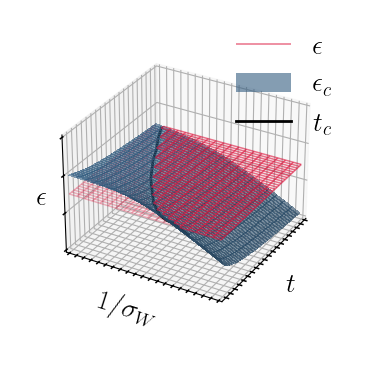

In [297]:
# epsilon = 0.01
epsilon = 0.1
# epsilon = 0.25

t_max = 40
t_list = np.arange(1, t_max)

sigma_list = np.logspace(-2, 2, 20)
   
XX, YY = np.meshgrid(t_list, sigma_list)
eps_c_list = epsilon_c(sigma_W=1./YY, r=r, t=XX)

def const_eps(x, y, eps):
    return 0.5*(x/x + y/y)*eps # To keep the shape

eps_init = const_eps(XX, YY, epsilon)

t_c_list = np.round(t_c(epsilon=epsilon, sigma_W=sigma_list, r=r))

valid1 = np.where(t_c_list > 0, t_c_list, np.nan)
valid_t = np.where(valid1 < t_max, valid1, np.nan)
eps_t_c_list = np.zeros((len(sigma_list)))
for i in range(len(sigma_list)):
    eps_t_c_list[i] = epsilon_c(sigma_W=sigma_list[i], r=r, t=valid_t[i])

n_fig = 1
fig = plt.figure(figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

ax = fig.add_subplot(projection='3d')

z1_masked = np.where(np.log10(eps_init) > np.log10(eps_c_list), np.log10(eps_init), np.nan)
z2_masked = np.where(np.log10(eps_init) < np.log10(eps_c_list), np.log10(eps_init), np.nan)

ax.plot_wireframe(XX, np.log10(YY), z1_masked, 
                  color='crimson', alpha=0.6, label=r"$\epsilon$")

ax.plot_wireframe(XX, np.log10(YY), z2_masked, 
                  color='crimson', alpha=0.3)

ax.plot_surface(XX, np.log10(YY), np.log10(eps_c_list), 
                color='steelblue', alpha = 0.6,
                rstride=1, cstride=1, antialiased=False,
                linewidth=1, shade=True,
                label=r"$\epsilon_c$")

ax.plot3D(valid_t, np.log10(1./sigma_list), np.log10(eps_t_c_list),
        marker='', lw=2, color='k', label=r"$t_c$")

ax.set_xlabel(r"$t$", labelpad=0)
ax.set_ylabel(r"$1/\sigma_W$", labelpad=0)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"$\epsilon$", labelpad=-10, rotation=0)

ax.set_xlim(t_max, 1)
ax.set_ylim(-2, 2)
ax.set_zlim(-4, 2)

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

ax.view_init(azim=30, elev=30)
ax.set_box_aspect(None, zoom=0.80)

plt.legend()

plt.tight_layout()

plt.savefig(plot_dir0 + "intro_phase_3d_eps%.2f.pdf"%(epsilon))

plt.show()

In [273]:
def simulate_time(epsilon, sigma, N, M, n_try, n_data, f, fp, data_dir, epochs):
    
    r = N/M
    
    # Load or generate data
    data_string = "dyn_N%d_r%.2f_eps%.5f_sig%.5f"%(N, r, epsilon, sigma)
    print(data_string)

    if data_string+"_data.npz" in os.listdir(data_dir):
        load = True
        print("Load data from "+data_dir+data_string+"_data.npz")
    else:
        load = False

    W_star = np.zeros((N, M))
    W_star[0][0] = 1
    README = ""

    if load:
        data = np.load(data_dir+data_string+"_data.npz")
        README = data["README"]
        W_list = data["W_list"]
        l_list = data["l_list"]
        dl_list = data["dl_list"]

        print("Data loaded from: "+data_dir+data_string+"_data.npz")
    else:
        print("=====")
        print("Generating ... ")
        W_list = np.zeros((n_try, epochs+1, N, M))
        l_list = np.zeros((n_try, epochs+1))
        dl_list = np.zeros((n_try))

        for n in range(n_try):
            data = np.random.normal(0., 1., size=(n_data, M))
            W0 = np.random.normal(0., sigma/np.sqrt(M), size=(N, M))

            W_list[n][0] = W0.copy()
            
            h_hat = data @ W0.T # n x M

            y_hat = f(h_hat) # n x M
            y = f(data @ W_star.T) # n x M

            l_ = 0.5*np.trace((y - y_hat) @ (y - y_hat).T)/n_data

            l_list[n][0] = l_.copy()
            
            W_ = W0.copy()
            
            for e in range(epochs):
                for _ in range(10):

                    dl = - np.mean(np.einsum("nM, nN, nN -> nNM", 
                                         data, y - y_hat, fp(h_hat)), 
                               axis=0)

                    dl_list[n] = np.linalg.norm(dl)

                    # Single Step Update
                    W_ = W_ - epsilon * dl

                    h_hat = data @ W_.T # n x M

                    y_hat = f(h_hat) # n x M
                    y = f(data @ W_star.T) # n x M

                    l_ = 0.5*np.trace((y - y_hat) @ (y - y_hat).T)/n_data

                l_list[n][e+1] = l_.copy()
                W_list[n][e+1] = W_.copy()

        # Generate the docstring
        README = """
        N: %d
        M: %d
        r: %.4f
        eps: %.4f
        sig: %.4f
        n_try: %d
        """%(N, M, r, epsilon, sigma, n_try)

        np.savez(data_dir+data_string+"_data.npz",
                 README = README,
                 W_list = W_list, 
                 l_list = l_list,
                 dl_list = dl_list,
                )

        print("Data saved to "+data_dir+data_string+"_data.npz")
        print(README)
        print("=====")

In [274]:
def calculate_dx_last(epsilon, sigma, data_dir, epoch=-1):
    # Load or generate data
    data_string = "dyn_N%d_r%.2f_eps%.5f_sig%.5f"%(N, r, epsilon, sigma)
    print("Loading " + data_string)

    with np.load(data_dir+data_string+"_data.npz") as data:
        W_list = data["W_list"][:, -1]

    Xp = np.einsum("nNM, nLM -> nNL", W_list, W_list)
    n = len(Xp)
    
    try:
        x, u = np.linalg.eig(Xp)
       
        diff = (x[:, 0] - x[:, 1]) / x[:, 0]
        q2_ = u[:, 0, 0]**2

        u_ab = []

        w_vec = W_list.reshape(len(W_list), -1)
        w_norm = w_vec / np.linalg.norm(w_vec, axis=-1, keepdims=True)
        w_ab = []

        for i in range(u.shape[0]):
            for j in range(i+1, u.shape[0]):
                u_ab.append(np.abs(np.sum(u[i, 0] * u[j, 0], axis=-1)))
                w_ab.append(np.abs(np.sum(w_norm[i] * w_norm[j], axis=-1)))

        u_ab = np.array(u_ab)
        w_ab = np.array(w_ab)
    
        W_star = np.zeros_like(W_list)
        W_star[:, 0, 0] = 1
        w_star = W_star.reshape(len(W_list), -1)
        w_st = np.sum(w_norm*w_star, axis=-1)**2
        
    except:
        diff = np.nan * np.ones((n))
        q2_ = np.nan * np.ones((n))
        u_ab = np.nan * np.ones(int(n*(n-1)/2))
        w_ab = np.nan * np.ones(int(n*(n-1)/2))
        w_st = np.nan * np.ones(int(n))

    return diff, q2_, u_ab, w_ab, w_st

In [275]:
epoch_list = [50, 100, 200]

q2_time = []

for epoch in epoch_list:
    data_dir = data_dir0+"epoch%d/"%(epoch)

    epsilon_list = np.logspace(-2, 2, 10)
    sigma_list = np.logspace(-2, 2, 10)

    try:
        with np.load(data_dir+"dyn_q2_diff_measure.npz") as data:
            diff_list = data["diff_list"]
            diff_err_list = data["diff_err_list"]
            q2_list_last = data["q2_list"]
            q2_err_list = data["q2_err_list"]
            u_ab_list = data["u_ab_list"]
            u_ab_err_list = data["u_ab_err_list"]
            w_ab_list = data["w_ab_list"]
            w_ab_err_list = data["w_ab_err_list"]
            w_st_list = data["w_st_list"]
            w_st_err_list = data["w_st_err_list"]

        print("Load from "+data_dir +"dyn_q2_diff_measure.npz")

    except:
        diff_list = np.zeros((len(sigma_list), len(epsilon_list)))
        diff_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        q2_list_last = np.zeros((len(sigma_list), len(epsilon_list)))
        q2_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        u_ab_list = np.zeros((len(sigma_list), len(epsilon_list)))
        u_ab_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        w_ab_list = np.zeros((len(sigma_list), len(epsilon_list)))
        w_ab_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        w_st_list = np.zeros((len(sigma_list), len(epsilon_list)))
        w_st_err_list = np.zeros((len(sigma_list), len(epsilon_list)))

        for i, epsilon in enumerate(epsilon_list):
            for j, sigma in enumerate(sigma_list):
                diff, q2_, u_ab, w_ab, w_st = calculate_dx_last(epsilon, sigma, data_dir, epoch=epoch)

                diff_list[j, i] = np.mean(diff, axis=0)
                diff_err_list[j, i] = np.std(diff, axis=0)

                q2_list_last[j, i] = np.mean(q2_, axis=0)
                q2_err_list[j, i] = np.std(q2_, axis=0)  

                u_ab_list[j, i] = np.mean(u_ab, axis=0)
                u_ab_err_list[j, i] = np.std(u_ab, axis=0)

                w_ab_list[j, i] = np.mean(w_ab, axis=0)
                w_ab_err_list[j, i] = np.std(w_ab, axis=0)

                w_st_list[j, i] = np.mean(w_st, axis=0)
                w_st_err_list[j, i] = np.std(w_st, axis=0)

        np.savez(data_dir+"dyn_q2_diff_measure.npz",
                 diff_list = diff_list,
                 diff_err_list = diff_err_list,
                 q2_list = q2_list_last,
                 q2_err_list = q2_err_list,
                 u_ab_list = u_ab_list,
                 u_ab_err_list = u_ab_err_list,
                 w_ab_list = w_ab_list,
                 w_ab_err_list = w_ab_err_list,
                 w_st_list = w_st_list,
                 w_st_err_list = w_st_err_list
                )

        print("Saved to "+data_dir +"dyn_q2_diff_measure.npz")

    print("done")
    
    q2_time.append(q2_list_last)
    
q2_time = np.array(q2_time)

Load from ../data/0.linear_full_batch/epoch50/dyn_q2_diff_measure.npz
done
Load from ../data/0.linear_full_batch/epoch100/dyn_q2_diff_measure.npz
done
Load from ../data/0.linear_full_batch/epoch200/dyn_q2_diff_measure.npz
done


/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_44150/2185999806.py:29: RuntimeWarning: invalid value encountered in power
  eps_n = np.where(1. - (1 - sigma_W * r**(0.25))**(-1./t)>0, 1. - (1 - sigma_W * r**(0.25))**(-1./t), np.nan)


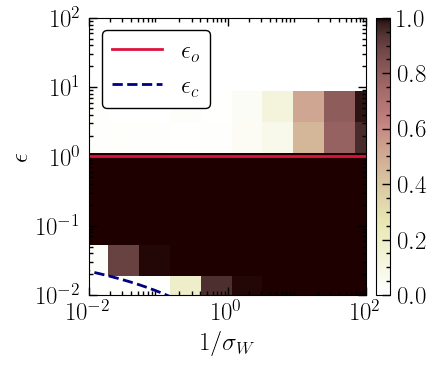

In [276]:
sigma_fine = np.logspace(-2, 2, 500)
eps_c = epsilon_c(sigma_fine, r=r, t=epoch)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=epoch)

set_rc(scale=1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, q2_time[-1].T,
                    vmin=0, vmax=1,
                    cmap='pink_r',
                    shading='auto')

# Optimal epsilon
axs.plot(1./sigma_list, np.ones_like(sigma_list), 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

# Critical step size
axs.plot(1./sigma_fine, eps_c, 
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sigma_fine, eps_c_n, 
         color='navy', marker='', ls='--', lw=2,)

plt.legend(loc='upper left', facecolor='white', frameon=True, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir0 + "linear_q2_exp_last%d.pdf"%(epoch), bbox_inches="tight")

plt.show()

/opt/miniconda3/envs/work/lib/python3.9/site-packages/global_chanju/paulplot/styles.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.tight_layout()
/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_44150/2185999806.py:29: RuntimeWarning: invalid value encountered in power
  eps_n = np.where(1. - (1 - sigma_W * r**(0.25))**(-1./t)>0, 1. - (1 - sigma_W * r**(0.25))**(-1./t), np.nan)
/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_44150/1933769420.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


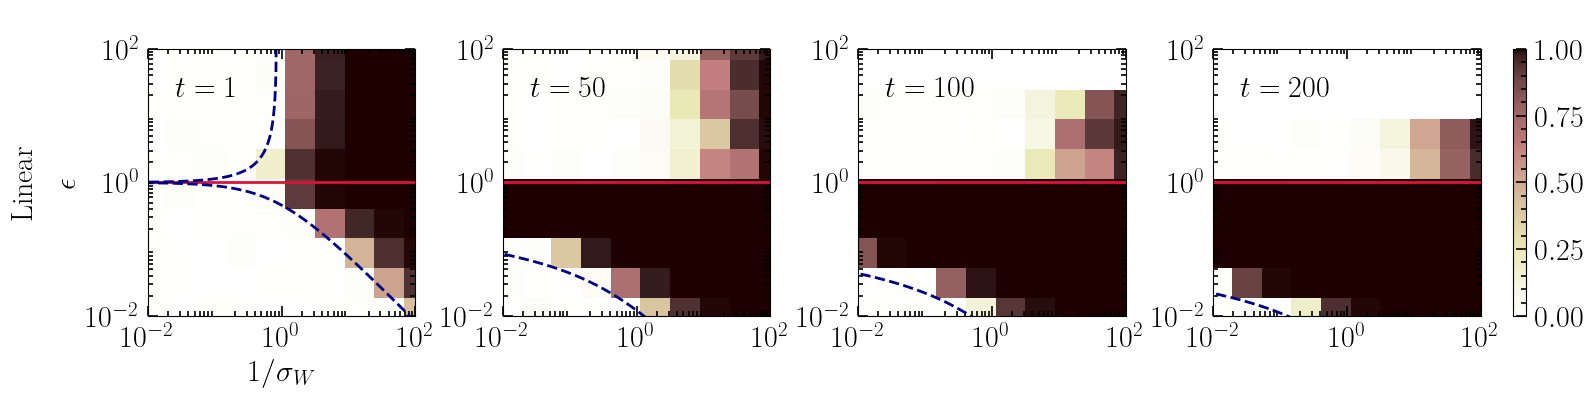

In [277]:
from matplotlib.gridspec import GridSpec

set_rc(scale=1.2)
n_fig = 5

fig = plt.figure(
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

sigma_fine = np.logspace(-2, 2, 500)
X, Y = np.meshgrid(sigma_list, epsilon_list)

gs = GridSpec(
    1, 5,
    width_ratios=[0.1, 1, 1, 1, 1],
    wspace=0.4
)

ax_title = fig.add_subplot(gs[0, 0])
ax_title.axis("off")

ax_title.text(
    0.5, 0.5,
    "Linear",
    rotation=90,
    va='center',
    ha='center',
#     fontsize=16
)

axes = []
pcm = None

# Initial
ax = fig.add_subplot(gs[0, 1])

pcm = ax.pcolormesh(
    1./X, Y, 
    q2_list.T,
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
ax.plot(
    1./sigma_list, np.ones_like(sigma_list), 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)


eps_c = epsilon_c(sigma_fine, r=r, t=1)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=1)
# Critical step size
ax.plot(
    1./sigma_fine, eps_c, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
ax.plot(
    1./sigma_fine, eps_c_n, 
    color='navy', marker='', ls='--', lw=2,
)

ax.text(
    0.1, 0.85,
    transform=ax.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"$t=1$"
)

nice_style(
    ax, 
    ylim=(1e-2, 1e2),
    xlim=(1e-2, 1e2),
        xlabel=r"$1/\sigma_W$",
        ylabel=r"$\epsilon$",
    logx=True, logy=True,
    xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
)

ax.set_aspect('equal')

axes.append(ax)

for i, epoch in enumerate(epoch_list):
    ax = fig.add_subplot(gs[0, i+2])
    eps_c = epsilon_c(sigma_fine, r=r, t=epoch)
    eps_c_n = epsilon_c_n(sigma_fine, r=r, t=epoch)

    pcm = ax.pcolormesh(
        1./X, Y, 
        q2_time[i].T,
        vmin=0, vmax=1,
        cmap='pink_r',
        shading='auto'
    )
    
    # Optimal epsilon
    ax.plot(1./sigma_list, np.ones_like(sigma_list), 
             color='crimson', marker='', ls='-', lw=2, 
             label=r"$\epsilon_o$")

    # Critical step size
    ax.plot(1./sigma_fine, eps_c, 
             color='navy', marker='', ls='--', lw=2,
             label=r"$\epsilon_c$")
    ax.plot(1./sigma_fine, eps_c_n, 
             color='navy', marker='', ls='--', lw=2,)
    
    ax.text(
        0.1, 0.85,
        transform=ax.transAxes,
        horizontalalignment='left', verticalalignment='center',
        color='k', 
        s=r"$t=%d$"%(epoch)
    )

    nice_style(
        ax, 
        ylim=(1e-2, 1e2),
        xlim=(1e-2, 1e2),
        logx=True, logy=True,
        xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
    )
    
    ax.set_aspect('equal')

    axes.append(ax)

    
cbar = fig.colorbar(
    pcm,
    ax=axes,
    location='right',
    shrink=0.77,
    pad=0.02
)

plt.tight_layout()

plt.savefig(plot_dir0+"linear_q2_time_dep.pdf")

plt.show()

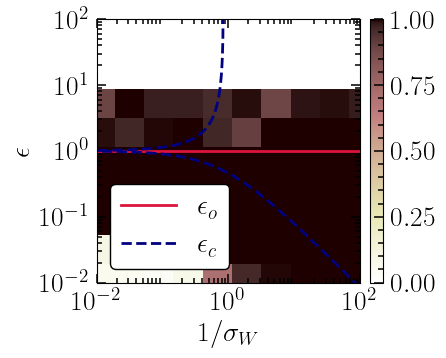

In [278]:
sigma_fine = np.logspace(-2, 2, 500)
eps_c = epsilon_c(sigma_fine, r=r, t=1)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=1)

set_rc(scale=1.1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, diff_list.T,
                    vmin=0, vmax=1,
                    cmap='pink_r',
                    shading='auto')

# Optimal epsilon
axs.plot(1./sigma_list, np.ones_like(sigma_list), 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

# Critical step size
axs.plot(1./sigma_fine, eps_c, 
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sigma_fine, eps_c_n, 
         color='navy', marker='', ls='--', lw=2,)

plt.legend(loc='lower left', facecolor='white', frameon=True, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

# plt.savefig(plot_dir0 + "linear_u_ab_exp.pdf", bbox_inches="tight")

plt.show()

# Finite size scaling

measuring  0 0.4
measuring  1 0.4105263157894737
measuring  2 0.4210526315789474
measuring  3 0.43157894736842106
measuring  4 0.4421052631578948
measuring  5 0.45263157894736844
measuring  6 0.4631578947368421
measuring  7 0.4736842105263158
measuring  8 0.4842105263157895
measuring  9 0.49473684210526314
measuring  10 0.5052631578947369
measuring  11 0.5157894736842106
measuring  12 0.5263157894736842
measuring  13 0.5368421052631579
measuring  14 0.5473684210526315
measuring  15 0.5578947368421052
measuring  16 0.5684210526315789
measuring  17 0.5789473684210527
measuring  18 0.5894736842105264
measuring  19 0.6
done
Saved the figure to ../data/0.linear_full_batch/q2_overlap_fss_N1024.npz


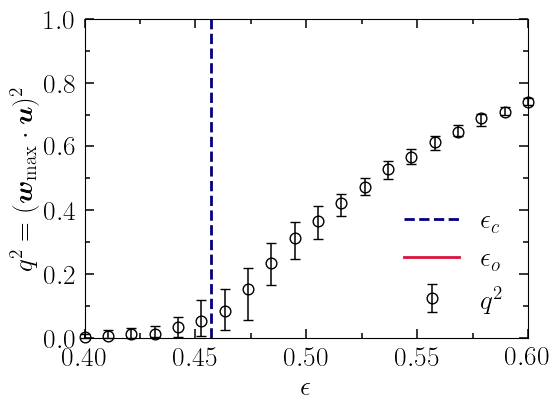

In [34]:
sigma = 1.
epsilon_list = np.linspace(0.4, 0.6, 20)

n = 50

# N = 128
# N = 256
# N = 512
N = 1024

M = N*2
r = N / M

figure_id = "q2_overlap_fss_N%d"%(N)

W_star = np.zeros((n, N, M))
W_star[:, 0, 0] = 1

try:
    with np.load(data_dir0+figure_id+".npz") as data:
        x_plot = data["x_plot"]
        y_mean = data["y_mean"]
        y_err = data["y_err"]
        x_list = data["x_list"]
        
    print("Loaded the figure from "+data_dir0+figure_id+".npz")
    
except:
    x_list = np.zeros((len(epsilon_list), n, N))
    q2_list = np.zeros((len(epsilon_list), n))

    for e, epsilon in enumerate(epsilon_list):
        print("measuring ", e, epsilon)
        W0 = np.random.normal(0., sigma/np.sqrt(M), size=(n, N, M))

        dl = - (W_star - W0)

        W_prime = W0 - epsilon * dl
        Xp = np.einsum("nac, nbc -> nab", W_prime, W_prime)
        x, u = np.linalg.eig(Xp)
        x_list[e] = x.copy()

        q2_ = u[:, 0, 0]**2
        q2_list[e] = q2_.copy()

    print("done")
    
    x_plot = epsilon_list
    med, err = asym_err(q2_list, axis=1)
    y_mean = med
    y_err = err
    
    np.savez(data_dir0+figure_id+".npz", 
             x_plot = x_plot,
             y_mean = y_mean,
             y_err = y_err,
             x_list = x_list,
             q2_list = q2_list
            )
    print("Saved the figure to "+data_dir0+figure_id+".npz")


n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

eps_c = epsilon_c(sigma, r, t=1)
axs.axvline(eps_c, 
            ls='--', lw=2, color='navy',
            label=r"$\epsilon_c$")

eps_0 = 1.
axs.axvline(eps_0,
            ls='-', color='crimson', lw=2,
            label=r"$\epsilon_o$")


axs.errorbar(x_plot, y_mean, yerr=y_err, 
             ls='', clip_on=False,
             color='k', label=r"$q^2$")


nice_style(axs, 
           xlim=(0.4, 0.6), ylim=(0.,1.), 
           xlabel=r"$\epsilon$", ylabel=r"$q^2 = (\boldsymbol{w}_{\rm max} \cdot \boldsymbol{u})^2$")

plt.legend(loc='lower right')

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

In [35]:
# L_list = np.array([25, 50, 100, 200]) # 1000 samples
L_list = np.array([128, 256, 512, 1024]) # 20 samples
figure_ids = ["q2_overlap_fss_N%d"%(d) for d in L_list]
x_plots = []
q2_lists = []

for fig_id in figure_ids:
    with np.load(data_dir0+fig_id+".npz") as data:
        x_plots.append(data["x_plot"])
#         q2_lists.append(data["q2_list"][:,:n])
        q2_lists.append(data["q2_list"])

q2_lists = np.array(q2_lists)

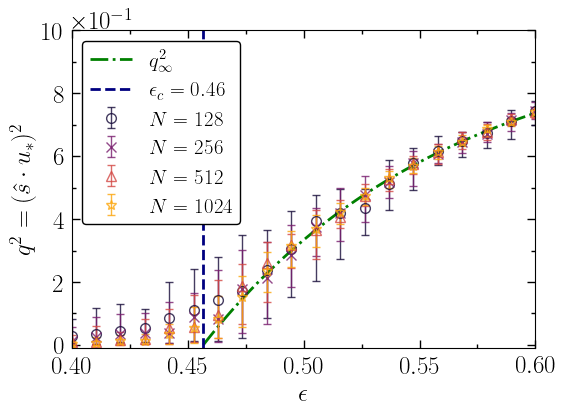

In [93]:
set_rc(scale=1)

figure_id = "q2_overlap_fss"

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))


eps_c = epsilon_c(sigma_W=1., r=0.5, t=1)
x_q2 = np.linspace(eps_c, 0.6, 100)
q2_pred = q2(x_q2, sigma_W=sigma, r=r, t=1)

axs.plot(x_q2, q2_pred, 
         marker='', lw=2, ls='-.', color='green', label=r"$q^2_{\infty}$")

axs.axvline(eps_c, ls='--', color='navy', lw=2,
            label=r"$\epsilon_c = %.2f$"%(eps_c))

# cmap = plt.cm.inferno_r(np.linspace(0.2, 0.9, len(L_list)))
cmap = plt.cm.inferno(np.linspace(0.1, 0.8, len(L_list)))

mean, err = asym_err(q2_lists, axis=-1)

for i in range(len(L_list)):
    axs.errorbar(x_plot, mean[i], yerr=err[:,i], ls='',
                 color=cmap[i], label=r"$N=%d$"%(L_list[i]), alpha=0.8)

nice_style(axs, 
           xlim=(0.4, 0.6), ylim=(-0.01, 1.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$q^2 = (\hat s \cdot u_{\ast})^2$")

plt.legend(
#     bbox_to_anchor=(1., 1.),
    loc='upper left', 
    facecolor='white', 
    framealpha=1, frameon=True, edgecolor='k', fontsize=15)

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

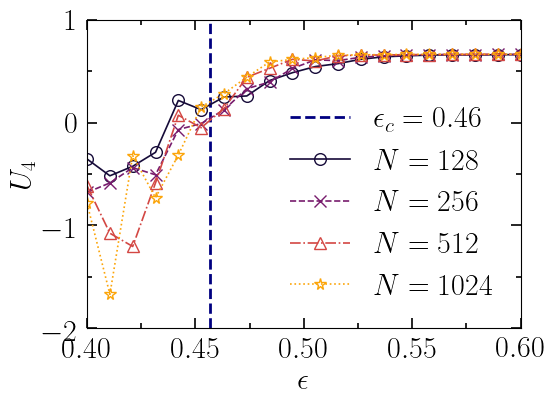

In [84]:
set_rc(scale=1.2)

U4 = 1. - np.mean(q2_lists**4, axis=-1)/(3. * np.mean(q2_lists**2, axis=-1)**2)

figure_id = "U4_fss"

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

ec_t = epsilon_c(sigma_W=1., r=0.5, t=1)

axs.axvline(ec_t, ls='--', color='navy', lw=2,
            label=r"$\epsilon_c = %.2f$"%(ec_t))

for i in range(len(L_list)):
    axs.plot(x_plot, U4[i], color=cmap[i], label=r"$N=%d$"%(L_list[i]))


nice_style(axs, 
           xlim=(0.4, 0.6), ylim=(-2., 1.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$U_4$")

plt.legend(loc='lower right', 
           facecolor='white', 
           framealpha=1., frameon=False, edgecolor='k')

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

In [38]:
def rho(L, rho_inf, c, theta):
    return rho_inf + c / (np.asarray(L)**theta)

In [39]:
def pade22(x, a0, a1, a2, b1, b2):
    return (a0 + a1 * x + a2 * x**2)/(1 + b1 * x + b2 * x**2)

In [40]:
def pade11(x, a0, a1, b1):
    return (a0 + a1 * x)/(1 + b1 * x)

In [41]:
def chisq_res(params, datas, pade, eps, ls):
    gc, rho_inf, c, theta = params[:4]
    pade_params = params[4:]
    
    res = []
    raw_x_all = []
    raw_U4_all = []
    
    per_block = []
    
    rho_L = rho(ls, rho_inf, c, theta)
    L_term = ls[:, None] ** rho_L[:, None]
    g_term = (eps[None, :] - gc)
    
    x = g_term * L_term

    m2 = np.mean(datas**2, axis=(-1))
    m4 = np.mean(datas**4, axis=(-1))

    U4 = 1. - m4/(3. * m2**2)
    
    x_flat = x.ravel()
    U4_flat = U4.ravel()
    
    F = pade(x_flat, *pade_params)
    
    return U4_flat - F

In [42]:
from scipy.optimize import least_squares

In [75]:
ec_t = epsilon_c(sigma_W=1., r=0.5, t=1)

# Pade22 good
guess = [
    ec_t, # gc
    0.66, # nu
    0.5, # c
    1., # theta
    0.25, 1.6, 0.36, 0.1, 1.6 # pade coeffs
]

bounds = (
    [ec_t - 0.1, 
     0., # rho_inf
     -2, # c
     0.01, # theta
     -np.inf, -np.inf, -10, # pade a
     -np.inf, -np.inf # pade b
    ],
    [ec_t + 0.1, 
     1., # rho_inf
     10, # c
     10, # theta
     1., 10, 10, # pade a
     10, 20 # pade b 
    ]
)

result = least_squares(
    chisq_res,
    guess,
    bounds = bounds,
    args=(q2_lists, pade22, x_plot, L_list),
#     method="trf"
)

ec = result.x[0]
print("ec", ec)
rho_inf = result.x[1]
print("rho_inf", rho_inf)
c = result.x[2]
print("c", c)
theta = result.x[3]
print("theta", theta)
pade_coeffs = result.x[4:]
print("pade coeffs", pade_coeffs)

ec 0.45758645756433325
rho_inf 0.25682084409553635
c -1.9999999999999998
theta 0.562436403392007
pade coeffs [ 0.15076613  6.36555748  6.7597281   4.26694452 18.29989883]


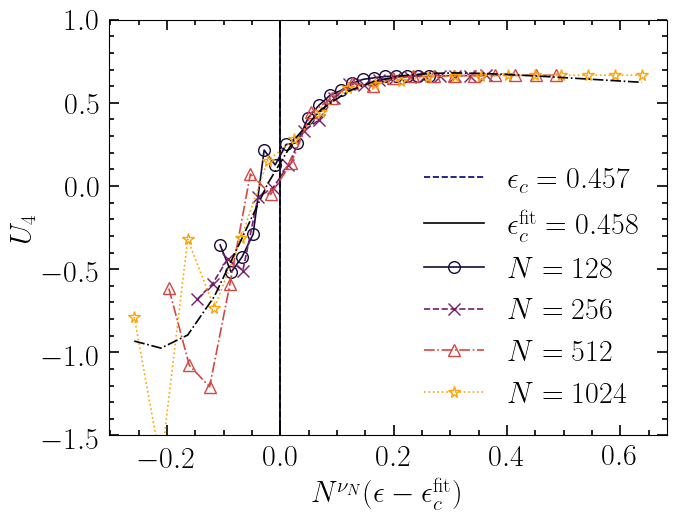

In [76]:
pade = pade22

plt.axvline(ec_t - ec, ls='--', label=r"$\epsilon_c = %.3f$"%(ec_t))
plt.axvline(0, ls='-', color='k', label=r"$\epsilon_c^{\rm fit} = %.3f$"%(ec))

rescale_L = L_list**rho(L_list, rho_inf, c, theta)

for i in range(len(L_list)):
    x_res = (x_plot - ec)*rescale_L[i]
    plt.plot(x_res, U4[i], color=cmap[i], label=r"$N=%d$"%(L_list[i]))

y_plot = pade(x_res, *pade_coeffs)
plt.plot(x_res, y_plot, color='k', alpha=1, marker='', ls='-.')

plt.legend()
plt.xlabel(r"$N^{\nu_N}(\epsilon - \epsilon_c^{\rm fit})$")
plt.ylabel(r"$U_4$")

# plt.xlim(-100, 100)
plt.ylim(-1.5, 1.)
plt.show()

In [86]:
# Jackknife

n = q2_lists.shape[-1]
q2_jk = np.empty((len(L_list), len(x_plot), n, n-1))
for L in range(len(L_list)):
    for e in range(len(x_plot)):
        for i in range(n):
            q2_jk[L,e,i] = np.r_[q2_lists[L,e,:i], q2_lists[L,e,i+1:]]

In [87]:
try:
    with np.load(data_dir0+"fss.npz") as file:
        results = file['results']
    print("Load")

except:
    results = np.zeros((n, len(guess)))

    # Pade22 good
    guess = [
        ec_t, # gc
        0.5, # rho_inf
        0.5, # c
        1., # theta
        0.25, 1.6, 0.36, 0.1, 1.6 # pade coeffs
    ]
    
    bounds = (
        [ec_t - 0.1, 
         0., # rho_inf
         -2, # c
         0.01, # theta
         0., 0., -10, # pade a
         0., 0. # pade b
        ],
        [ec_t + 0.1, 
         3, # rho_inf
         10, # c
         10, # theta
         1., 10, 10, # pade a
         10, 20 # pade b 
        ]
    )

    for i in range(n):
        guess = [
            ec_t, # gc
            np.random.uniform(0.4, 0.6), # rho_inf
            np.random.uniform(0.4, 0.6), # c
            np.random.uniform(0.8, 1.2), # theta
            np.random.uniform(0.1, 0.5), # a0
            np.random.uniform(1., 2.), # a1
            np.random.uniform(0.2, 0.5), # a2
            np.random.uniform(0.01, 0.5), # b1
            np.random.uniform(1., 2.) # b2
        ]

        result = least_squares(
            chisq_res,
            guess,
            bounds = bounds,
            args=(q2_jk[:,:,i], pade22, x_plot, L_list),
            method="trf"
        )

        if i % 100 == 0:
            print(i, result.x[0])

        results[i] = result.x.copy()
    np.savez(data_dir0+"fss.npz", results=results)
    print("Saved")

Load


0.4573667371732272
0.004722642864018523


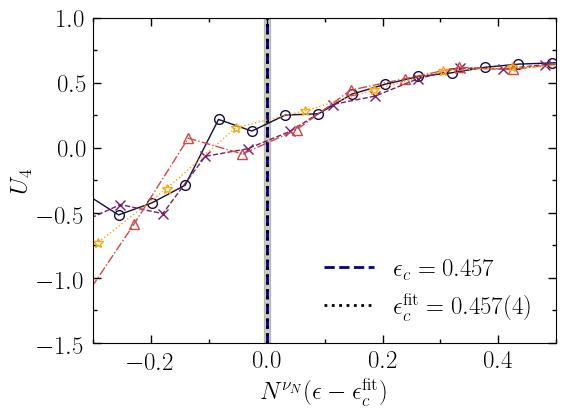

In [88]:
set_rc(scale=1)

means = np.mean(results, axis=0)
errs = np.sqrt(19)*np.std(results, axis=0)
ec_jk = means[0]
ec_err_jk = errs[0]
print(ec_jk)
print(ec_err_jk)

rho_inf_jk = means[1]
c_jk = means[2]
theta_jk = means[3]

figure_id = "U4_fit_fss"

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

pade = pade22

axs.axvline(ec_t - ec_jk, ls='--', lw=2, color='navy',
            label=r"$\epsilon_c = %.3f$"%(ec_t))

axs.axvline(0, ls=':', lw=2, color='k',
            label=r"$\epsilon_c^{\rm fit} = %.3f (4)$"%(ec_jk))
axs.fill_between(np.linspace(-ec_err_jk, ec_err_jk), -1.5, 1, alpha=0.2, color='k')

rescale_L = L_list**rho(L_list, rho_inf_jk, c_jk, theta_jk)

for i in range(len(L_list)):
    x_res = (x_plot - ec_jk)*rescale_L[i]
    axs.plot(x_res, U4[i], color=cmap[i], )#label=r"$N=%d$"%(L_list[i]))

nice_style(axs, 
           xlim=(-0.3, 0.5), 
           ylim=(-1.5, 1.), 
           xlabel=r"$N^{\nu_N}(\epsilon - \epsilon_c^{\rm fit})$", 
           ylabel=r"$U_4$")

plt.legend(loc='lower right', 
           facecolor='white', 
           framealpha=1., frameon=False, edgecolor='k')

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

0.4573667371732272
0.034244517244942416


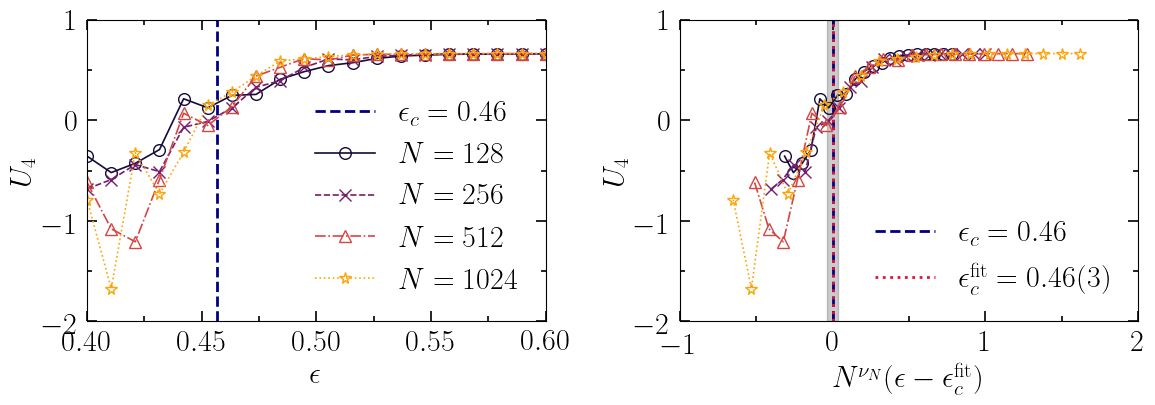

In [92]:
set_rc(scale=1.2)

U4 = 1. - np.mean(q2_lists**4, axis=-1)/(3. * np.mean(q2_lists**2, axis=-1)**2)

figure_id = "U4_fss_fit"

n_fig = 2
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

ec_t = epsilon_c(sigma_W=1., r=0.5, t=1)

axs[0].axvline(ec_t, ls='--', color='navy', lw=2,
            label=r"$\epsilon_c = %.2f$"%(ec_t))

for i in range(len(L_list)):
    axs[0].plot(x_plot, U4[i], 
                color=cmap[i],
                label=r"$N=%d$"%(L_list[i]))


nice_style(axs[0], 
           xlim=(0.4, 0.6), ylim=(-2., 1.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$U_4$")

axs[0].legend(
    loc='lower right', 
    facecolor='white', 
    framealpha=1., frameon=False, edgecolor='k')

###########

means = np.mean(results, axis=0)
errs = np.sqrt(999)*np.std(results, axis=0)
ec_jk = means[0]
ec_err_jk = errs[0]
print(ec_jk)
print(ec_err_jk)

rho_inf_jk = means[1]
c_jk = means[2]
theta_jk = means[3]

pade = pade22

axs[1].axvline(ec_t - ec_jk, ls='--', lw=2, color='navy',
            label=r"$\epsilon_c = %.2f$"%(ec_t))

axs[1].axvline(0, ls=':', lw=2, color='crimson',
            label=r"$\epsilon_c^{\rm fit} = %.2f (3)$"%(ec_jk))
axs[1].fill_between(np.linspace(-ec_err_jk, ec_err_jk), -2, 1, alpha=0.2, color='k')

rescale_L = L_list**rho(L_list, rho_inf_jk, c_jk, theta_jk)

for i in range(len(L_list)):
    x_res = (x_plot - ec_jk)*rescale_L[i]
    axs[1].plot(x_res, U4[i], color=cmap[i])#label=r"$N=%d$"%(L_list[i]))

nice_style(axs[1], 
           xlim=(-1, 2.), 
           ylim=(-2, 1.), 
           xlabel=r"$N^{\nu_N}(\epsilon - \epsilon_c^{\rm fit})$", 
           ylabel=r"$U_4$")

axs[1].legend(loc='lower right', 
           facecolor='white', 
           framealpha=1., frameon=False, edgecolor='k')


plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()